In [7]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

In [8]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [9]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:absoluteerror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  MAE = mean_absolute_error(y_val, predictions)
  return MAE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_MAE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_MAE
print("XGBoost Error:", XGBoost_Error)

[I 2026-01-23 17:15:18,206] A new study created in memory with name: no-name-01f854a8-f190-42f8-81bc-57d760916f7b
[I 2026-01-23 17:15:19,315] Trial 0 finished with value: 491.39142470285685 and parameters: {'learning_rate': 0.011565278939446838, 'max_depth': 4, 'subsample': 0.7896303382644925, 'colsample_bytree': 0.8873261864269261}. Best is trial 0 with value: 491.39142470285685.
[I 2026-01-23 17:15:20,561] Trial 1 finished with value: 589.9936940089409 and parameters: {'learning_rate': 0.08842719054589275, 'max_depth': 3, 'subsample': 0.8944343985273586, 'colsample_bytree': 0.7970088358808853}. Best is trial 0 with value: 491.39142470285685.
[I 2026-01-23 17:15:21,862] Trial 2 finished with value: 533.935990486738 and parameters: {'learning_rate': 0.04193742547362371, 'max_depth': 3, 'subsample': 0.7760127150673506, 'colsample_bytree': 0.6988910974699165}. Best is trial 0 with value: 491.39142470285685.
[I 2026-01-23 17:15:23,473] Trial 3 finished with value: 560.4130065601724 and pa

Optimal Parameters: {'learning_rate': 0.011565278939446838, 'max_depth': 4, 'subsample': 0.7896303382644925, 'colsample_bytree': 0.8873261864269261}
XGBoost Error: 665.0718618395412


Sample0: True = 665.00s, Predicted = 900.24s, Error=235.24s
Sample1: True = 897.75s, Predicted = 906.09s, Error=8.34s
Sample2: True = 1377.25s, Predicted = 897.16s, Error=480.09s
Sample3: True = 1545.00s, Predicted = 899.89s, Error=645.11s
Sample4: True = 1230.00s, Predicted = 871.31s, Error=358.69s
Sample5: True = 803.75s, Predicted = 940.16s, Error=136.41s
Sample6: True = 790.00s, Predicted = 865.60s, Error=75.60s
Sample7: True = 1196.25s, Predicted = 1057.46s, Error=138.79s
Sample8: True = 920.00s, Predicted = 830.64s, Error=89.36s
Sample9: True = 715.00s, Predicted = 1043.68s, Error=328.68s
Sample10: True = 1223.75s, Predicted = 962.16s, Error=261.59s
Sample11: True = 1396.25s, Predicted = 895.26s, Error=500.99s
Sample12: True = 1448.75s, Predicted = 1079.12s, Error=369.63s
Sample13: True = 1446.25s, Predicted = 1047.62s, Error=398.63s
Sample14: True = 1505.00s, Predicted = 1082.02s, Error=422.98s
Sample15: True = 615.00s, Predicted = 1091.13s, Error=476.13s
Sample16: True = 868.75

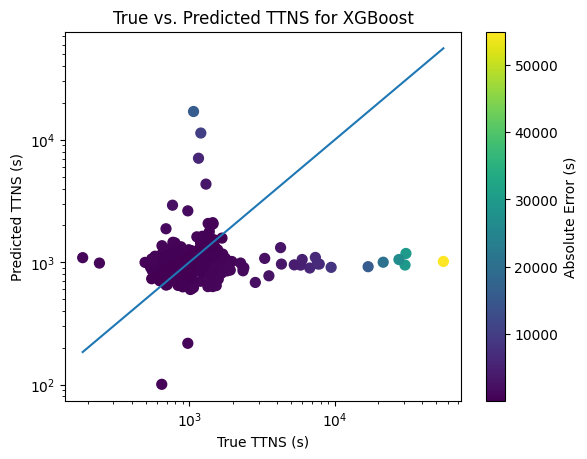

In [11]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()